In [1]:
# BLASTP Homology Search

#This notebook performs:

#1. Environment setup
#2. BLAST+ availability check
#3. FASTA quality assessment
#4. BLASTP homology search against reference protein database
#5. BLAST result filtering
#6. Candidate export for downstream annotation

In [2]:
from __future__ import annotations

import os
import sys
import shutil
import subprocess
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import pandas as pd

print(f"Python version: {sys.version}")

Python version: 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]


In [3]:
current_dir = Path.cwd().resolve()

candidate_roots = [
    current_dir,
    current_dir.parent
]

project_root = None

for root in candidate_roots:
    if (root / "data").exists():
        project_root = root
        break

if project_root is None:
    project_root = current_dir


data_dir = project_root / "data"
results_dir = project_root / "results"

data_dir.mkdir(exist_ok=True)
results_dir.mkdir(exist_ok=True)


print(f"Project root: {project_root}")
print(f"Data directory: {data_dir}")
print(f"Results directory: {results_dir}")

Project root: C:\Metisa_plana_Target_Mining
Data directory: C:\Metisa_plana_Target_Mining\data
Results directory: C:\Metisa_plana_Target_Mining\results


In [4]:
blastp_path = shutil.which("blastp")

if blastp_path is None:
    raise FileNotFoundError(
        "BLASTP was not found. Please run 01_BLAST_Setup_Installer.ipynb first."
    )

print(f"blastp found at:")
print(blastp_path)


blast_version = subprocess.run(
    [blastp_path, "-version"],
    capture_output=True,
    text=True
)

print(blast_version.stdout)

blastp found at:
C:\Users\nurly\OneDrive\Documents\UKM\BioHackathon\blast-2.17.0+\bin\blastp.EXE
blastp: 2.17.0+
 Package: blast 2.17.0, build Jul  1 2025 08:57:20



In [5]:
def parse_fasta(fasta_path):

    sequences = []

    current_id = None
    current_seq = []

    with open(fasta_path, "r") as handle:

        for line in handle:

            line = line.strip()

            if not line:
                continue

            if line.startswith(">"):

                if current_id:
                    sequences.append(
                        (current_id, "".join(current_seq))
                    )

                current_id = line[1:].split()[0]
                current_seq = []

            else:
                current_seq.append(line)


    if current_id:
        sequences.append(
            (current_id, "".join(current_seq))
        )

    return sequences

In [6]:
query_candidates = [

    data_dir / "metisa_plana_proteins.fasta",

    project_root / "data" / "metisa_plana_proteins.fasta",

    project_root.parent / "data" / "metisa_plana_proteins.fasta"

]


query_file = None


for candidate in query_candidates:

    if candidate.exists():

        query_file = candidate
        break



if query_file is None:

    raise FileNotFoundError(
        "Metisa plana FASTA file not found."
    )


print("FASTA file:")
print(query_file)

FASTA file:
C:\Metisa_plana_Target_Mining\data\metisa_plana_proteins.fasta


In [7]:
seqs = parse_fasta(query_file)


lengths = [
    len(seq)
    for _, seq in seqs
]


valid = []
invalid = []


allowed = set(
    "ACDEFGHIKLMNPQRSTVWY*X-"
)


for seq_id, seq in seqs:

    if not seq or any(
        aa not in allowed
        for aa in seq
    ):
        invalid.append(seq_id)

    else:
        valid.append(seq_id)



print(f"Total proteins: {len(seqs)}")
print(f"Valid proteins: {len(valid)}")
print(f"Invalid proteins: {len(invalid)}")

print(f"Minimum length: {min(lengths)} aa")
print(f"Maximum length: {max(lengths)} aa")
print(f"Average length: {sum(lengths)/len(lengths):.2f} aa")

Total proteins: 26490
Valid proteins: 26490
Invalid proteins: 0
Minimum length: 5 aa
Maximum length: 18909 aa
Average length: 362.94 aa


In [8]:
print("Example protein IDs:")

for seq_id, seq in seqs[:5]:

    print(
        f"{seq_id} : {len(seq)} aa"
    )


if invalid:

    print("\nWarning:")
    print(invalid[:10])

Example protein IDs:
g1.t1 : 236 aa
g2.t1 : 99 aa
g3.t1 : 344 aa
g4.t1 : 534 aa
g5.t1 : 581 aa


In [9]:
def find_blast_db():

    candidates = [

        # Inside project folder
        project_root / "BLAST" / "swissprot",

        project_root / "BLAST" / "uniprot_sprot",

        # Inside data folder
        data_dir / "swissprot",

        data_dir / "uniprot_sprot",

        data_dir / "ref_db",

        # Default BLAST location
        Path("C:/BLAST/swissprot"),

    ]


    for db in candidates:

        if db.exists():

            return db


    return None



blast_db = find_blast_db()


if blast_db is None:

    raise FileNotFoundError(
        """
BLAST database not found.

Checked:
- project/BLAST/swissprot
- data/swissprot
- C:/BLAST/swissprot
"""
    )


print("BLAST database found:")
print(blast_db)

BLAST database found:
C:\Metisa_plana_Target_Mining\BLAST\swissprot


In [ ]:
blast_output = results_dir / "blast_results.tsv"


blast_command = [

    blastp_path,

    "-query",
    str(query_file),

    "-db",
    str(blast_db),

    "-evalue",
    "1e-5",

    "-max_target_seqs",
    "5",

    "-outfmt",
    "6 qseqid sseqid pident length qcovs evalue bitscore stitle",

    "-out",
    str(blast_output)

]


print("Running BLASTP...")


result = subprocess.run(
    blast_command,
    capture_output=True,
    text=True
)


print("Return code:")
print(result.returncode)


print(
    f"Output saved: {blast_output}"
)

Running BLASTP...


In [ ]:
blast_columns = [

    "qseqid",
    "sseqid",
    "pident",
    "length",
    "qcovs",
    "evalue",
    "bitscore",
    "stitle"

]


blast_df = pd.read_csv(

    blast_output,

    sep="\t",

    names=blast_columns

)


blast_df.head()

,qseqid,sseqid,pident,length,qcovs,evalue,bitscore,stitle


In [ ]:
strong = (

    (blast_df.pident >= 50) &
    (blast_df.qcovs >= 50) &
    (blast_df.evalue <= 1e-5)

)


moderate = (

    (blast_df.pident >= 30) &
    (blast_df.qcovs >= 70) &
    (blast_df.evalue <= 1e-10)

)


blast_df["classification"] = "weak"


blast_df.loc[
    strong,
    "classification"
] = "strong"


blast_df.loc[
    moderate,
    "classification"
] = "moderate"



candidate_df = blast_df[
    blast_df.classification != "weak"
]


print(
    candidate_df["classification"].value_counts()
)

Series([], Name: count, dtype: int64)


In [ ]:
candidate_output = (
    results_dir /
    "blast_candidates.tsv"
)


candidate_df.to_csv(

    candidate_output,

    sep="\t",

    index=False

)


print(
    f"Saved: {candidate_output}"
)

Saved: C:\Metisa_plana_Target_Mining\results\blast_candidates.tsv


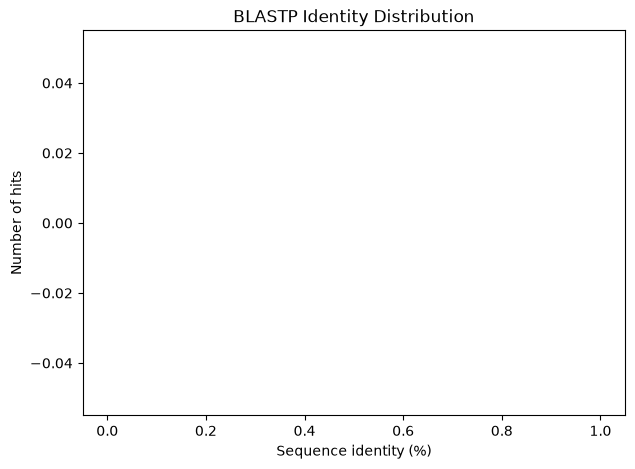

In [ ]:
plt.figure(figsize=(7,5))


plt.hist(
    blast_df["pident"],
    bins=30
)


plt.xlabel(
    "Sequence identity (%)"
)

plt.ylabel(
    "Number of hits"
)


plt.title(
    "BLASTP Identity Distribution"
)


plt.show()

In [ ]:
print("BLASTP workflow completed")

print(
    f"Total hits: {len(blast_df)}"
)

print(
    f"Candidate hits: {len(candidate_df)}"
)

print(
    f"Saved file: {candidate_output}"
)

BLASTP workflow completed
Total hits: 0
Candidate hits: 0
Saved file: C:\Metisa_plana_Target_Mining\results\blast_candidates.tsv
